# TQD2026 notebook 2: *MPS thermal states*
## Imaginary time-evolution approach

This notebook contains two examples:

1. Imaginary-time projection of a random MPS under a nearest-neighbour Heisenberg Hamiltonian, compared with the DMRG ground-state energy.
2. A purification construction for a finite-temperature state. Physical and ancilla sites are interleaved; nearest-neighbour physical interactions become 3-site-span terms on the enlarged chain. The purified result is compared with a direct Taylor-series expansion of `exp(-beta H)` on the original physical Hilbert space.

<center>
<img src="images/thermnal_state.png" width="400">
</center>

In [1]:
using ITensors
using ITensorMPS
using LinearAlgebra
using Plots
using Printf
using Random

include("MPS_MPO_helpers.jl")
using .MPS_MPO_helpers

default(; linewidth=2, grid=false, framestyle=:box)

## 1. Imaginary-Time Projection To The Ground State

Define the Hamiltonian `OpSum` and then construct an MPO from this for the spin-1/2 Heisenberg model.

In [2]:
N_project = 20
sites_project = siteinds("S=1/2", N_project)

H_project_ops = OpSum()
for j in 1:(N_project - 1)
  H_project_ops += "Sz", j, "Sz", j + 1
  H_project_ops += 0.5, "S+", j, "S-", j + 1
  H_project_ops += 0.5, "S-", j, "S+", j + 1
end

H_project = MPO(H_project_ops, sites_project);

Now apply the DMRG eigensolver to directly find the ground state:

In [3]:
Random.seed!(2026)
energy_dmrg, psi_dmrg = dmrg(
  H_project,
  random_mps(sites_project; linkdims=8);
  nsweeps=8,
  maxdim=[10, 20, 40, 80, 120, 160, 200, 200],
  cutoff=1e-11,
  outputlevel=0,
)

println(@sprintf("DMRG ground-state energy density = %.12f", energy_dmrg/N_project))

DMRG ground-state energy density = -0.434123666705


For a positive imaginary-time step `tau`, the helper constructs a one-step MPO approximating `exp(-tau H)`. Repeatedly applying it to a generic random MPS filters out excited-state components. After enough steps the energy approaches the DMRG ground-state energy. You will notice that imaginary time-evolution is noticeably slower than DMRG since it is a power eigensolver.

In [4]:
tau_project = 0.05
nsteps_project = 220

layers_project = second_order_trotter_circuit(
  H_project_ops,
  sites_project,
  tau_project;
  evolution_factor=-1,
)
Utau_project = circuit_mpo(layers_project, sites_project; cutoff=1e-13)

Random.seed!(2027)
psi_project = random_mps(ComplexF64, sites_project; linkdims=8)
normalize!(psi_project)

projection_times = Float64[]
projection_energies = Float64[]

for step in 0:nsteps_project
  push!(projection_times, step * tau_project)
  push!(projection_energies, expect_MPO(psi_project, H_project))

  step == nsteps_project && break
  psi_project = apply_mpo_step(Utau_project, psi_project; cutoff=1e-11, maxdim=200)
end

println(@sprintf("final projected energy = %.12f", projection_energies[end]))
println(@sprintf("absolute energy error = %.3e", abs(projection_energies[end] - energy_dmrg)))

final projected energy = -8.669390310060
absolute energy error = 1.308e-02


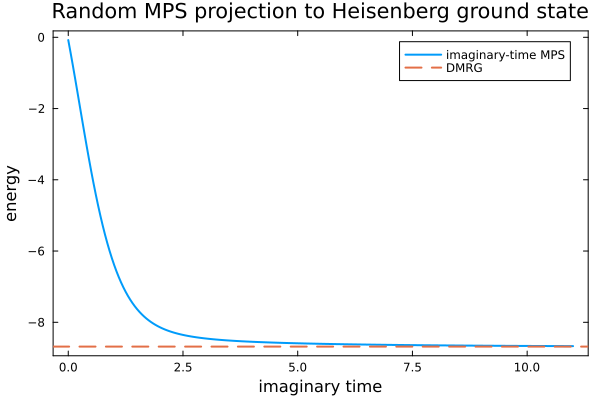

In [5]:
plot(
  projection_times,
  projection_energies;
  xlabel="imaginary time",
  ylabel="energy",
  label="imaginary-time MPS",
  title="Random MPS projection to Heisenberg ground state",
  legend=:topright,
)
hline!([energy_dmrg]; linestyle=:dash, label="DMRG")

Compare the energy density computed from this finite-length open chain with the analytic Bethe anstaz result for the chain in the thermodynamic limit. Try pushing $N_{\rm project}$ bigger to see if how fast you can converge to the exact result.

In [6]:
projection_energies[end]/N_project

-0.43346951550298424

In [7]:
1/4-log(2) # Bethe ansatz

-0.4431471805599453

Compute and plot the spin-spin correlations of the ground state via imaginary time-evolution: 

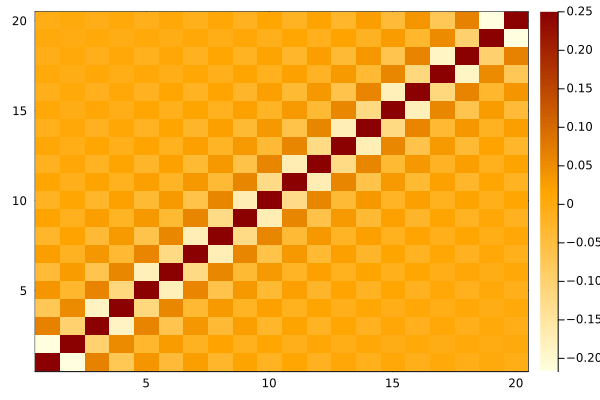

In [8]:
zzcorr = real(correlation_matrix(psi_project,"Sz","Sz"));
gr()
heatmap(1:N_project, 1:N_project, zzcorr, c = :heat)

Plot them from the centre of the system outwards:

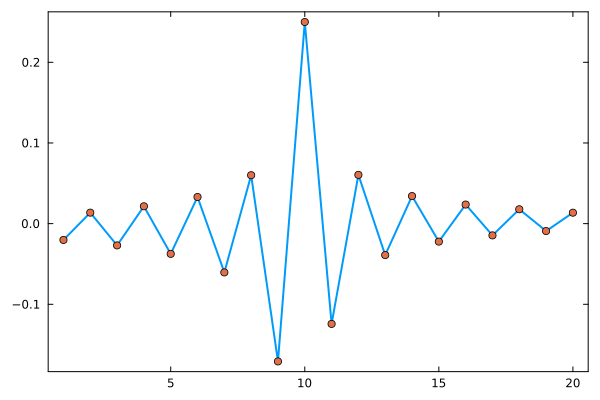

In [9]:
plot(1:N_project, zzcorr[Int(ceil(N_project/2)),:], label=false)  
scatter!(1:N_project, zzcorr[Int(ceil(N_project/2)),:], label=false) 

Notice the staggered pattern in the correlations is consistent with the ground state being antiferromagnetic.

## 2. Purification Of A Thermal State

Begin by using a more conventional direct construction of the thermal density operator via a Taylor series expansion of `exp(-β H)` using the MPO for `H` and repeatedly multiplying this MPO with itself (and compressing). We begin by constructing the convention MPO for `H`:

In [21]:
N_phys = 10
β_high = 0.1
sites_phys = siteinds("S=1/2", N_phys)

H_phys_ops = OpSum()

for j in 1:(N_phys - 1)
  H_phys_ops += "Sz", j, "Sz", j + 1
  H_phys_ops += 0.5, "S+", j, "S-", j + 1
  H_phys_ops += 0.5, "S-", j, "S+", j + 1
end

H_phys = MPO(H_phys_ops, sites_phys);

Compute a low-order power-series expansion using multiplications of the Hamiltonian MPO and adding them up to build an approximate MPO for the thermal state density operator. This will only be accurate for small β, so high temperature: 

In [22]:
ρT = exp_series(H_phys, β_high, sites_phys; order=3) # ρT = I - β H + β^2/2 H^2 - β^3/6 H^3 + ...   

Z_ser = tr(ρT)
ρT = ρT / Z_ser
energy_ser = inner(ρT, H_phys)/N_phys
 
println(@sprintf("series energy density = %.12f", energy_ser))
println(@sprintf("series partition function estimate = %.12f", Z_ser))

series energy density = -0.017275054610
series partition function estimate = 1032.784000000000


In the purification approach the enlarged chain is ordered as

`physical_1, ancilla_1, physical_2, ancilla_2, ...`.

Hence physical and ancilla sites are interlevaed. The infinite-temperature state is represented by a product of Bell pairs between each physical site and its ancilla. To represent `rho(beta) = exp(-beta H)`, we evolve the purified ket by `exp(-beta H / 2)` acting on the physical sites only. Since the physical sites are separated by ancillas, nearest-neighbour physical interactions become 3-site-span terms in the enlarged chain. We start by constructing this Hamiltonian, the Trotter circuit MPO for its imaginary time-evolution and the maximally entangled physical-ancilla initial state:

In [23]:
sites_pur = siteinds("S=1/2", 2N_phys)
physical_site(j) = 2j - 1

H_pur_ops = OpSum()
for j in 1:(N_phys - 1)
  p = physical_site(j)
  q = physical_site(j + 1)
  H_pur_ops += "Sz", p, "Sz", q
  H_pur_ops += 0.5, "S+", p, "S-", q
  H_pur_ops += 0.5, "S-", p, "S+", q
end

H_pur = MPO(H_pur_ops, sites_pur);

layers_beta = second_order_trotter_circuit(
  H_pur_ops,
  sites_pur,
  tau_beta;
  evolution_factor=-1,
  max_range=3,
)
Utau_beta = circuit_mpo(layers_beta, sites_pur; cutoff=1e-13)

psi_0 = maximally_entangled_pairs(sites_pur);

Now run several imaginary time-evolutions to reach different temperatures:

In [25]:
betas = [β_high, 1, 10]
dβ = 0.01
entropy_bond::Integer = N_phys

runs = Dict{Any,Any}()

for beta in betas
  println("Running beta = $beta")

  runs[beta] = (
    Z = Float64[],
    energy = Float64[],
    entropies = Float64[],
    maxlinkdims = Int[],
  )

  # The purified ket evolves for beta/2, since its norm and expectation values
  # contain one factor of exp(-beta H/2) from the bra and one from the ket.
  nsteps_beta = round(Int, (beta / 2) / dβ)

  psi_beta = copy(psi_0)

  for _ in 1:nsteps_beta
    psi_beta = apply_mpo_step(Utau_beta, psi_beta; cutoff=1e-12, maxdim=200, normalize=false)
  end

  push!(runs[beta].energy, expect_MPO(psi_beta, H_pur)/N_phys)
  push!(runs[beta].entropies, half_chain_entropy(psi_beta; bond=entropy_bond))
  push!(runs[beta].maxlinkdims, maxlinkdim(psi_beta))
  push!(runs[beta].Z, real(inner(psi_beta, psi_beta)) * 2.0^N_phys)

  println(@sprintf("purification energy density = %.12f", runs[beta].energy[end]))
  println(@sprintf("purification partition function estimate = %.12f", runs[beta].Z[end]))
end

Running beta = 0.1
purification energy density = -0.017279681572
purification partition function estimate = 1032.817430893472
Running beta = 1.0
purification energy density = -0.186091003319
purification partition function estimate = 2582.441182983509
Running beta = 10.0
purification energy density = -0.422312074010
purification partition function estimate = 3467437921342073856.000000000000


Plot the z-z correlations of the final low temperature case for comparison with the ground state earlier:

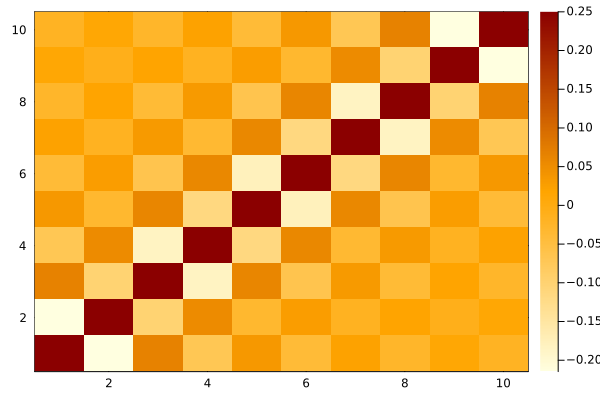

In [26]:
zzcorr = real(correlation_matrix(psi_beta,"Sz","Sz"));
zzcorr = zzcorr[1:2:2N_phys,1:2:2N_phys];
gr()
heatmap(1:N_phys, 1:N_phys, zzcorr, c = :heat)

As expected the lowest temperature correlation agrees qualitatively with the zero temperature plot from earlier.